In [1]:
import sys
from pathlib import Path
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import HistGradientBoostingClassifier

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Sklearn - evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Model saving
import os
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

root_path = Path.cwd().parent 
if str(root_path) not in sys.path:
    sys.path.insert(0, str(root_path))
from pipelines.data_pipeline import load_processed_data
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load cleaned data
df =load_processed_data("city_traffic_processed.csv")
Target = 'Severity'
print(f"Data shape: {df.shape}")
df.info()

Data shape: (500000, 164)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Columns: 164 entries, Severity to Cty_wake
dtypes: float64(12), int64(152)
memory usage: 625.6 MB


In [3]:
string_cols = df.select_dtypes(include=['object']).columns.tolist()

# Find all columns that are 'category' (if you used categorical types)
category_cols = df.select_dtypes(include=['category']).columns.tolist()

print(f"String columns: {string_cols}")
print(f"Category columns: {category_cols}")

String columns: []
Category columns: []


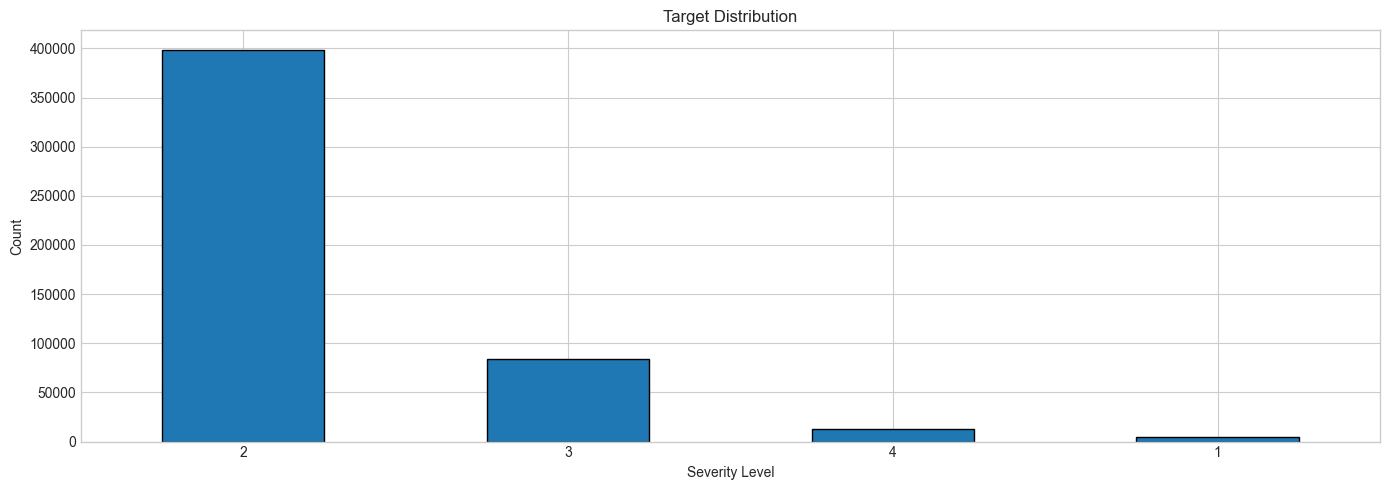

In [4]:
# Visualize the binned distribution
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Binned category counts
df[Target].value_counts().plot(kind='bar', ax=ax, edgecolor='black')
ax.set_xlabel('Severity Level')
ax.set_ylabel('Count')
ax.set_title('Target Distribution')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [5]:
# Check class balance
class_counts = df[Target].value_counts()
class_percentages = df[Target].value_counts(normalize=True) * 100

print("Class Distribution:")
for cat in class_counts.index:
    print(f"{cat}: {class_counts[cat]} ({class_percentages[cat]:.1f}%)")

# Check for severe imbalance
min_class_pct = class_percentages.min()
if min_class_pct < 10:
    print(f"\nWarning: Smallest class is only {min_class_pct:.1f}% of data.")
    print("Consider adjusting your binning strategy.")
else:
    print(f"\nClass balance looks reasonable!")

Class Distribution:
2: 398335 (79.7%)
3: 84063 (16.8%)
4: 13244 (2.6%)
1: 4358 (0.9%)

Consider adjusting your binning strategy.


In [6]:
#400,000 rows with 252 features take a very long time to train

# for testing, manually create a balanced 20,000 rows dataset
'''
df_sample = df.groupby(Target, group_keys=False)\
              .apply(lambda x: x.sample(n=min(len(x), 4000), random_state=42))\
              .reset_index(drop=True)

df_sample.shape

df_sample['Target'].value_counts()
'''

"\ndf_sample = df.groupby(Target, group_keys=False)              .apply(lambda x: x.sample(n=min(len(x), 4000), random_state=42))              .reset_index(drop=True)\n\ndf_sample.shape\n\ndf_sample['Target'].value_counts()\n"

In [7]:
datetime_cols = df.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns

print(datetime_cols)

Index([], dtype='object')


In [8]:
time_cols = df.columns[df.columns.str.contains('time', case=False)]

print(time_cols)

Index([], dtype='object')


In [9]:
X = df.drop(columns=[Target]).copy()
y = df[Target]

In [10]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique().tolist()}")

Features shape: (500000, 163)
Target shape: (500000,)

Features used: ['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Geo_Cluster', 'dist_from_reg_hotspot', 'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour', 'word_accident', 'word_exit', 'word_blocked', 'word_incident', 'word_lane', 'word_traffic', 'word_caution', 'word_drive', 'word_slow', 'word_closed', 'word_right', 'word_northbound', 'word_southbound', 'word_stationary', 'word_eastbound', 'word_westbound', 'word_shoulder', 'word_left', 'word_crash', 'word_delays', 'weather_data_available', 'is_freezing', 'low_visibility_severity', 'has_precipitation', 'weather_cluster_clear', 'weather_cluster_cloudy', 'weather_cluster_low_visibility

In [11]:
# TODO: Encode your target labels to numbers using LabelEncoder
#
# Steps:
# 1. Create a LabelEncoder instance
# 2. Fit and transform y to create y_encoded
#
# Hint: label_encoder.fit_transform(y)

# YOUR CODE HERE:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [12]:
# Verify encoding (run this to check)
print("Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Label encoding:
1 -> 0
2 -> 1
3 -> 2
4 -> 3


In [13]:
# TODO: Split your data with stratification
#
# Requirements:
# - 80/20 split (test_size=0.2)
# - random_state=42 for reproducibility
# - stratify=y_encoded (THIS IS THE KEY DIFFERENCE FROM REGRESSION!)
#   This ensures each class is proportionally represented in train/test
#
# Store in: X_train, X_test, y_train, y_test

# YOUR CODE HERE:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    test_size=0.2, # 30% of data for testing
    random_state=42, # for reproducibility
    stratify=y_encoded # this is the key parameter for stratification
)

In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))

for k,v in class_weights.items():    
    print(f"{k}: {v:.2f}")

0: 28.68
1: 0.31
2: 1.49
3: 9.44


In [15]:
# Verify split and stratification
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f" {c} ({c/len(y_train)*100:.1f}%)")

Training set: 400000 samples
Test set: 100000 samples

Training class distribution:
 3487 (0.9%)
 318668 (79.7%)
 67250 (16.8%)
 10595 (2.6%)


In [16]:
# TODO: Scale your features using StandardScaler
#
# Same as regression:
# 1. Create StandardScaler instance
# 2. fit_transform on X_train
# 3. transform (only!) on X_test
#
# Store in: X_train_scaled, X_test_scaled

# YOUR CODE HERE:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [17]:
# Convert to DataFrame (helpful for later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

SELECTED_FEATURES = X.columns.tolist()
print("Features scaled successfully!")
print(f"Scaler fitted on {len(SELECTED_FEATURES)} features.")

Features scaled successfully!
Scaler fitted on 163 features.


In [18]:
!pip install xgboost

In [19]:
# xgbclassifier clearly out-performs the other two models
# use xgboost to build and evaluate key matrics


model = HistGradientBoostingClassifier(
    max_iter=100, 
    max_depth=5, 
    random_state=42
)

model.fit(X_train_scaled, y_train)

model_name = 'Gradient Boosting'



In [43]:
from xgboost import XGBClassifier

weights = y_train.map(class_weights)

# 2. Remove scale_pos_weight from the model definition
model = XGBClassifier(
    n_estimators=100, 
    max_depth=5, 
    gamma=1,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42,
    objective='multi:softprob'
)

# 3. Pass the weights here
model.fit(X_train_scaled, y_train, sample_weight=weights)

AttributeError: 'numpy.ndarray' object has no attribute 'map'

In [35]:
model.fit(X_train_scaled, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [36]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [37]:
print (f"'Train Accuracy': {accuracy_score(y_train, y_train_pred):.4f}")

'Train Accuracy': 0.9020


In [38]:
print (f"'Test Accuracy': {accuracy_score(y_test, y_test_pred):.4f}")

'Test Accuracy': 0.9006


In [39]:
print (f"'Precision (weighted)': {precision_score(y_test, y_test_pred, average='weighted'):.4f}")

'Precision (weighted)': 0.8986


In [40]:
print (f"'Recall (weighted)': {recall_score(y_test, y_test_pred, average='weighted'):.4f}")

'Recall (weighted)': 0.9006


In [41]:
print (f"'F1 (weighted)': {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

'F1 (weighted)': 0.8972


In [42]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_test_pred, target_names=["1", "2", "3", "4"]))
print(confusion_matrix(y_test, y_test_pred))

              precision    recall  f1-score   support

           1       0.75      0.43      0.54       871
           2       0.92      0.96      0.94     79667
           3       0.78      0.73      0.75     16813
           4       0.95      0.51      0.67      2649

    accuracy                           0.90    100000
   macro avg       0.85      0.66      0.73    100000
weighted avg       0.90      0.90      0.90    100000

[[  373   488    10     0]
 [  119 76119  3367    62]
 [    5  4582 12210    16]
 [    2  1135   151  1361]]


### Model 1: Traffic Accident Severity — Traditional ML

- Multi-class classification: predict accident severity (1-4 scale)
- This dataset has significant class imbalance — your approach to handling it will be a key evaluation criterion. **Weighted F1 is the real evaluation metric**, not accuracy.
- Use classical ML algorithms (XGBoost, Random Forest, Gradient Boosting, etc.)
- Must be interpretable — city planners need to understand WHY an intersection is flagged as high-risk
- **Minimum Benchmark:** Accuracy > 70%, weighted F1 > 0.55
- **Stretch Goal:** Accuracy > 80%, weighted F1 > 0.70
- **Required:** SHAP or feature importance analysis — which factors most predict severe accidents?

In [27]:

################################# Feature Importance Analysis and Plot #########################################
#print(model.feature_importances_)


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# get importances
importances = model.feature_importances_

# if X_train is a DataFrame, use its column names
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# keep top 30
top_n = 30
feat_imp = feat_imp.sort_values("importance", ascending=False).head(top_n)

feat_imp1 = feat_imp.sort_values("importance", ascending=True).head(top_n)

print("\nTop 30 most important features:")
for i, row in feat_imp1.tail(30).iloc[::-1].iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")


# plot
plt.figure(figsize=(10, 8))
plt.barh(feat_imp["feature"][::-1], feat_imp["importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Feature Importances")
plt.tight_layout()
plt.show()

AttributeError: 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'

In [ ]:

################################# SHAP Explainer and Plot #########################################
#!pip install shap


In [29]:
import shap

# create explainer (TreeExplainer is optimized for XGBoost)
explainer = shap.TreeExplainer(model)

# compute SHAP values (use a sample for speed if needed)
X_sample = X_train.sample(100000, random_state=42)

shap_values = explainer.shap_values(X_sample)

In [ ]:
# Top drivers for all classes
for i in range(4):
    print('*****************************')
    print(f"Traffic Severity Level: {i+1}")
    
    shap.summary_plot(shap_values[:,:,i], X_sample)

In [ ]:
# Top drivers for the most severe accidents (level 4) in clear bar chart
shap.summary_plot(shap_values[:,:,3], X_sample, plot_type="bar")

In [ ]:

# Define path relative to notebook
model_path = "../models/model1_traditional_ml/xgb_model.pkl"

# Create folder if not exists
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save model
joblib.dump(model, model_path)

print(f"Model saved to {model_path}")